In [4]:
import pystac
import numpy as np
import rasterio
import os

In [5]:
url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

collection = pystac.Collection.from_file(url)

print("Collection loaded ✅")

Collection loaded ✅


In [6]:
items = collection.get_items()

# Take reference item
ref_item = next(items)

# Get centroid of reference
coords = ref_item.geometry['coordinates'][0]
ref_lon = np.mean([pt[0] for pt in coords])
ref_lat = np.mean([pt[1] for pt in coords])

print("Reference location:", ref_lat, ref_lon)

# Collect GEO images from same location
geo_same_location = []

for item in collection.get_items():
    try:
        # Filter GEO only
        if "GEO" not in item.id:
            continue
        
        coords = item.geometry['coordinates'][0]
        lon = np.mean([pt[0] for pt in coords])
        lat = np.mean([pt[1] for pt in coords])
        
        # Same location condition
        if abs(lat - ref_lat) < 0.01 and abs(lon - ref_lon) < 0.01:
            geo_same_location.append(item)
        
        if len(geo_same_location) == 30:
            break
            
    except:
        continue

print("Collected GEO images:", len(geo_same_location))

Reference location: 19.411717967999998 -155.280959954
Collected GEO images: 30


In [7]:
unique_items = {}

for item in geo_same_location:
    dt = item.properties.get('datetime')
    date = dt[:10]  # YYYY-MM-DD
    
    if date not in unique_items:
        unique_items[date] = item

temporal_stack = list(unique_items.values())

print("Unique temporal images:", len(temporal_stack))

Unique temporal images: 30


In [8]:
temporal_stack = sorted(
    temporal_stack,
    key=lambda x: x.properties.get('datetime')
)

print("Sorted timestamps:")

for item in temporal_stack:
    print(item.properties.get('datetime'))

Sorted timestamps:
2025-08-20T09:24:26.017706Z
2025-08-21T07:56:14.670657Z
2025-08-23T08:21:10.365099Z
2025-08-24T06:52:59.354868Z
2025-08-25T17:22:05.268186Z
2025-08-27T05:49:43.572820Z
2025-08-30T04:46:27.368248Z
2025-09-02T03:43:11.221863Z
2025-09-05T02:39:55.151206Z
2025-09-08T01:36:38.327151Z
2025-09-11T00:33:23.955348Z
2025-09-13T23:30:07.526525Z
2025-09-16T22:26:51.637630Z
2025-09-19T21:23:35.922479Z
2025-09-28T18:13:47.605659Z
2025-10-01T17:10:29.994377Z
2025-10-04T16:07:14.827536Z
2025-10-07T15:03:59.816280Z
2025-10-10T14:00:42.790093Z
2025-10-13T12:57:27.001281Z
2025-10-16T11:54:11.705763Z
2025-10-19T10:50:55.014356Z
2025-10-22T09:47:39.843659Z
2025-10-25T08:44:23.600333Z
2025-10-28T07:41:08.051239Z
2025-10-31T06:37:51.703736Z
2025-11-03T05:34:36.248627Z
2025-11-06T04:31:19.292211Z
2025-11-09T03:28:02.304377Z
2025-11-12T02:24:47.676937Z


In [9]:
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

images = []

for item in temporal_stack:
    url = item.assets['preview'].href
    
    with rasterio.open(url) as src:
        img = src.read(1, out_shape=(1, 256, 256))
    
    images.append(img)

images = np.array(images)

print("Final image stack shape:", images.shape)

Final image stack shape: (30, 256, 256)


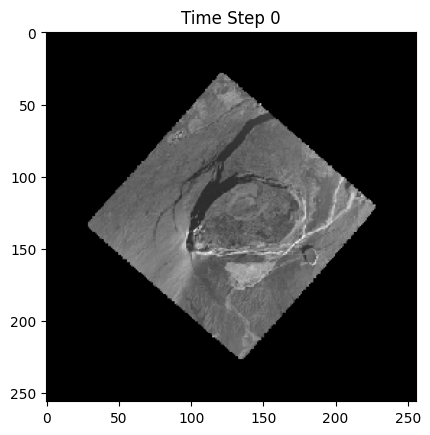

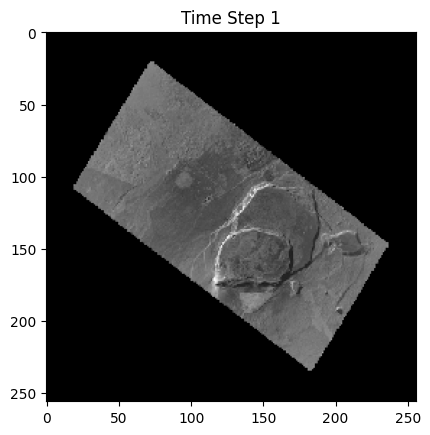

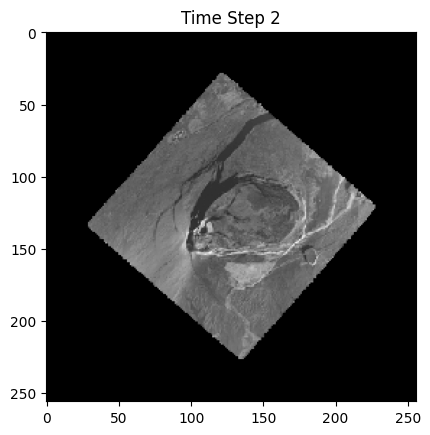

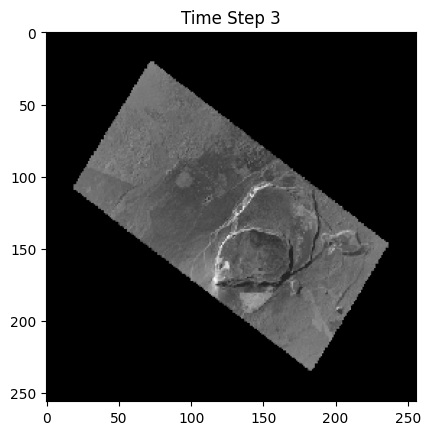

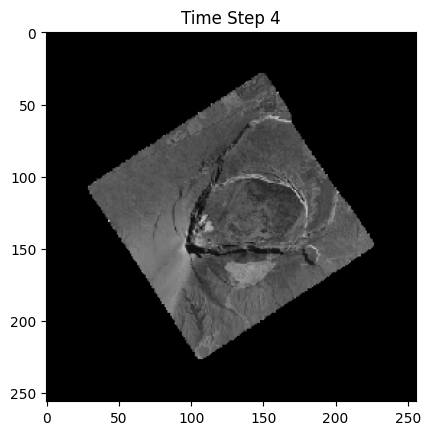

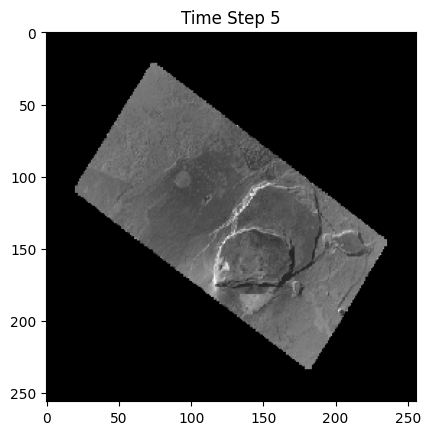

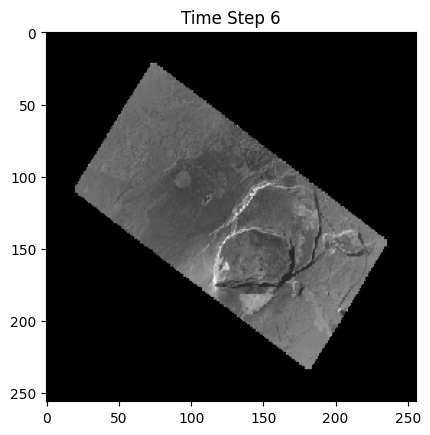

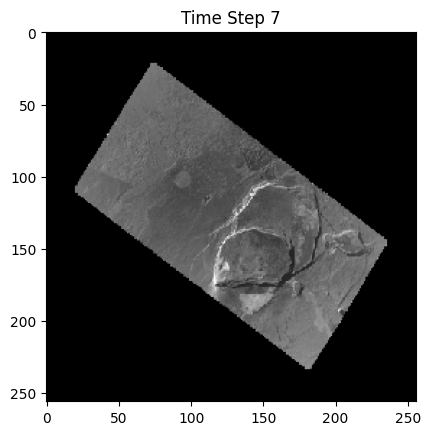

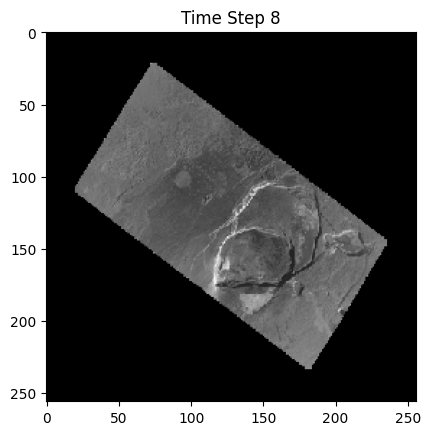

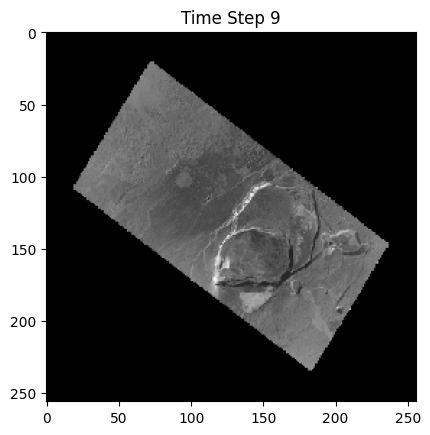

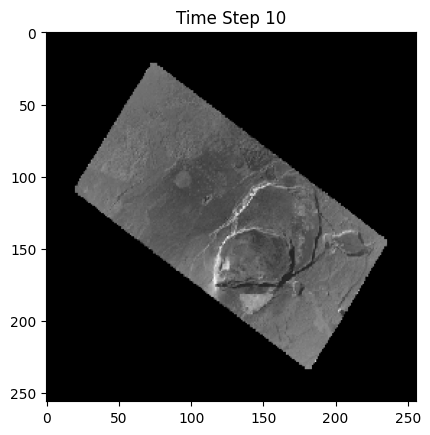

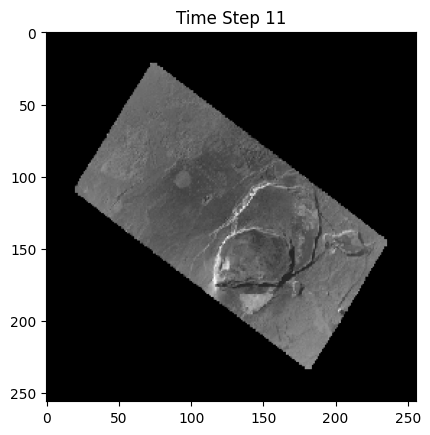

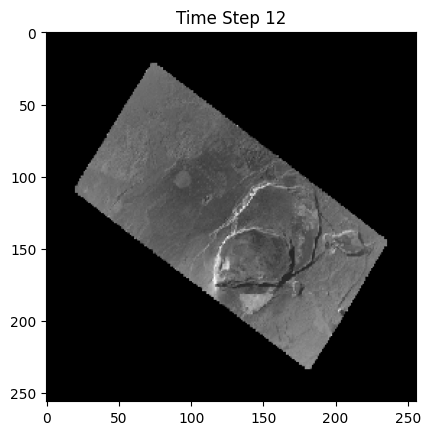

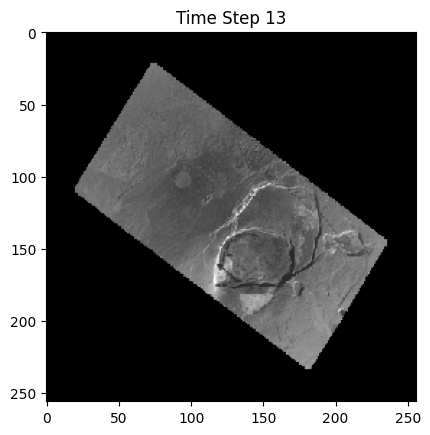

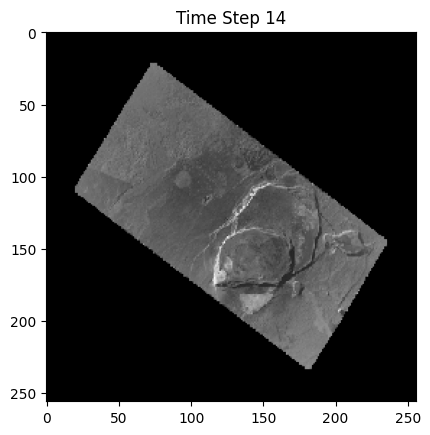

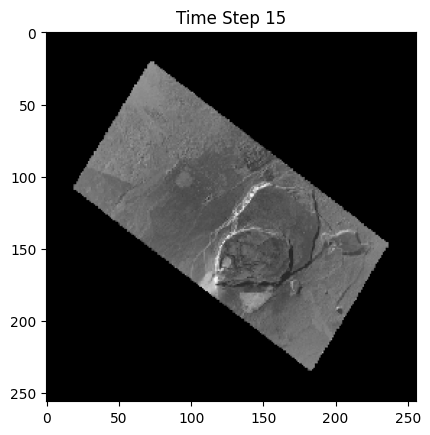

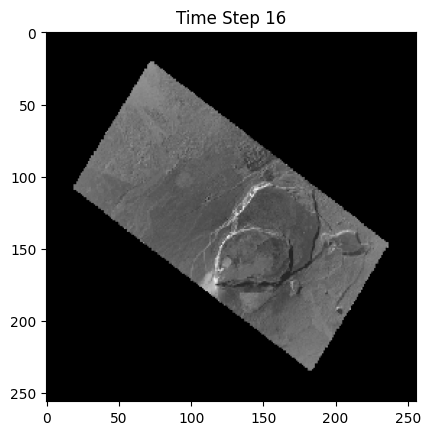

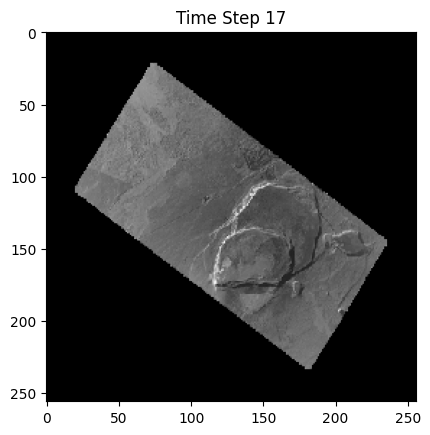

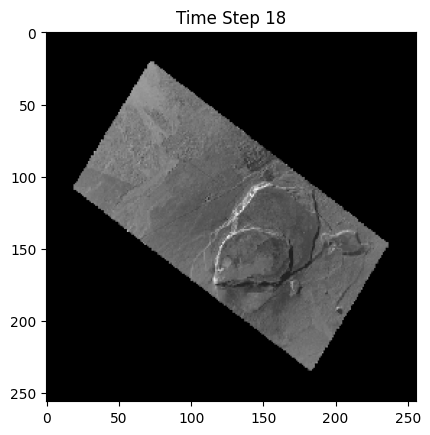

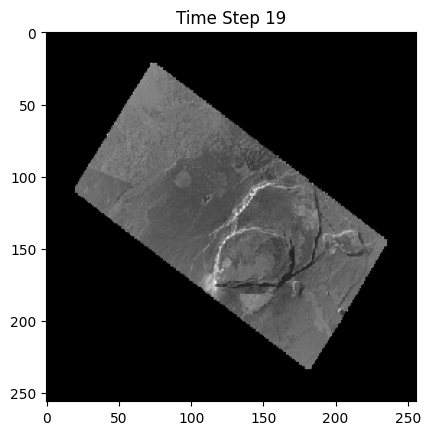

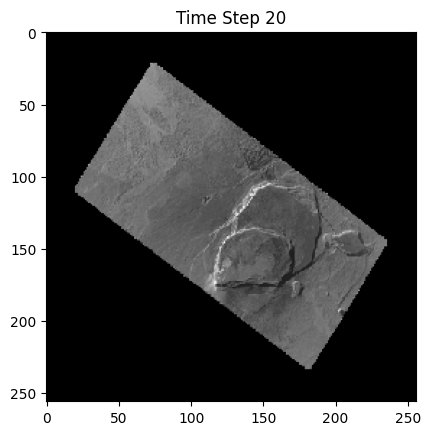

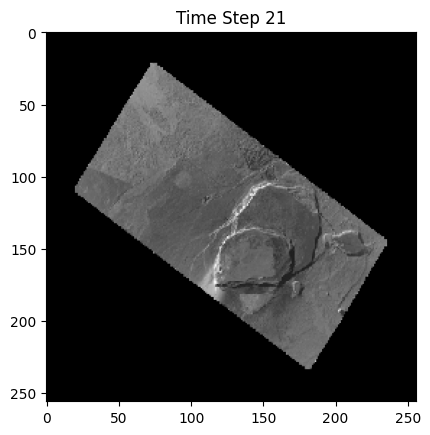

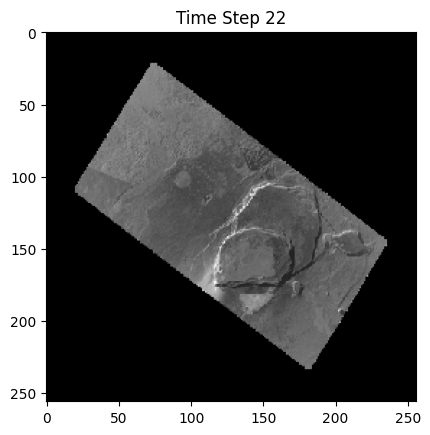

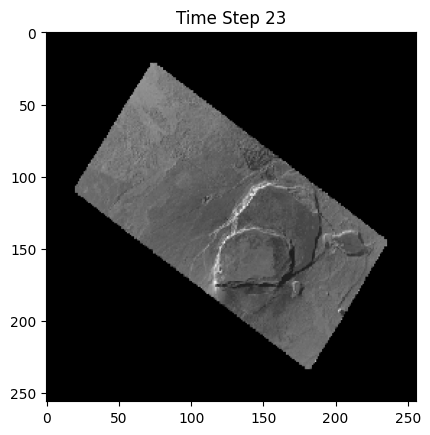

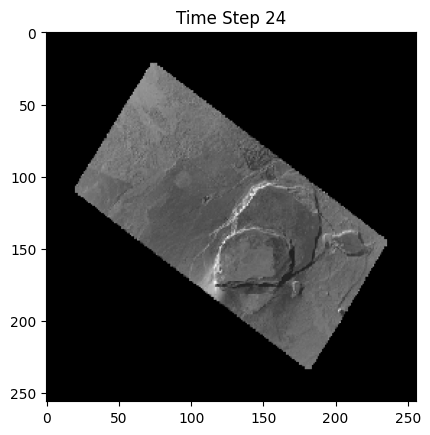

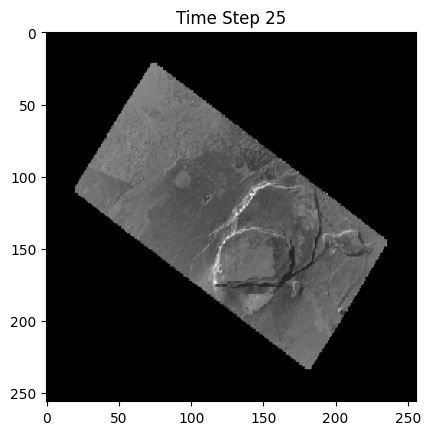

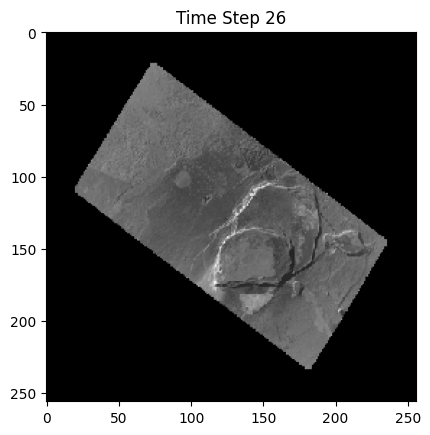

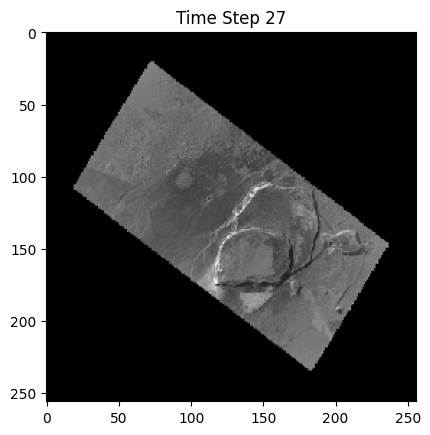

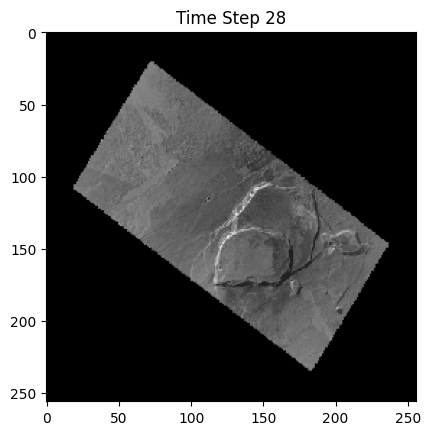

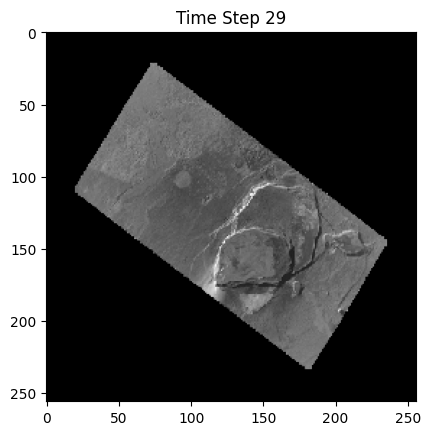

In [10]:
import matplotlib.pyplot as plt

for i in range(len(images)):
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Time Step {i}")
    plt.show()

In [13]:
#Autoencoder + Clustering (Unsupervised Temporal Analysis)
#Learn compressed representation of SAR images

In [14]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# images shape: (T, 256, 256)
images = images.astype('float32')

# Normalize (IMPORTANT)
images = (images - images.min()) / (images.max() - images.min())

# Convert to tensor
images_torch = torch.tensor(images).unsqueeze(1)  # (T,1,256,256)
images_torch = images_torch.to(device)

print(images_torch.shape)

torch.Size([30, 1, 256, 256])


In [15]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Bottleneck
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*32*32, 64)
        self.fc2 = nn.Linear(64, 64*32*32)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 2, stride=2), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        
        x = self.flatten(x)
        x = self.fc1(x)   # compressed feature
        
        x = self.fc2(x)
        x = x.view(-1, 64, 32, 32)
        
        x = self.decoder(x)
        return x

In [16]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    optimizer.zero_grad()
    
    output = model(images_torch)
    loss = criterion(output, images_torch)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2794
Epoch 2, Loss: 0.2736
Epoch 3, Loss: 0.2598
Epoch 4, Loss: 0.2346
Epoch 5, Loss: 0.2030
Epoch 6, Loss: 0.1753
Epoch 7, Loss: 0.1541
Epoch 8, Loss: 0.1350
Epoch 9, Loss: 0.1167
Epoch 10, Loss: 0.1000


In [17]:
with torch.no_grad():
    encoded = model.encoder(images_torch)
    encoded = encoded.view(encoded.size(0), -1)

features = encoded.cpu().numpy()

print("Feature shape:", features.shape)

Feature shape: (30, 65536)


In [55]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(features)

print(labels)

[1 0 1 2 1 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0]


In [56]:
import numpy as np
unique, counts = np.unique(labels, return_counts=True)

print(dict(zip(unique, counts)))

{0: 14, 1: 3, 2: 13}


In [57]:
for i, lbl in enumerate(labels):
    if lbl == 1:
        print(i, temporal_stack[i].properties['datetime'])

0 2025-08-20T09:24:26.017706Z
2 2025-08-23T08:21:10.365099Z
4 2025-08-25T17:22:05.268186Z


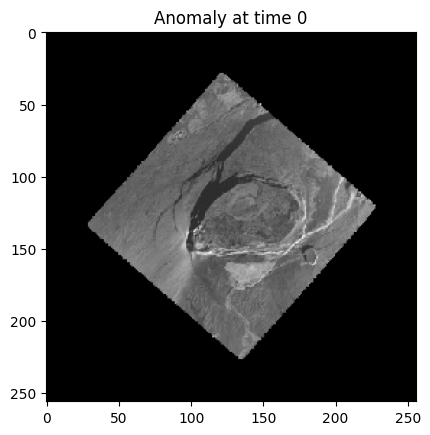

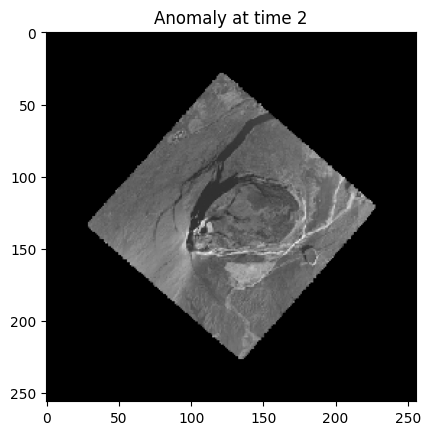

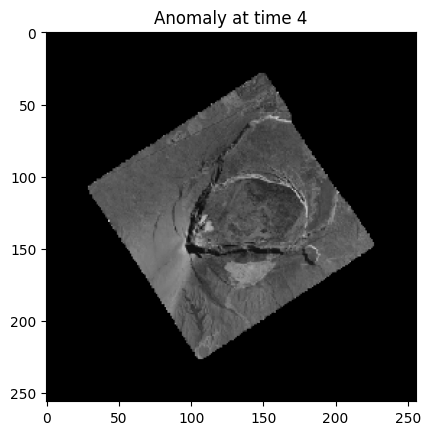

In [58]:
import matplotlib.pyplot as plt

for i, lbl in enumerate(labels):
    if lbl == 1:
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Anomaly at time {i}")
        plt.show()

In [59]:
for i, lbl in enumerate(labels):
    if lbl == 1:
        print(temporal_stack[i].properties)

{'proj:centroid': {'lon': -155.28253975, 'lat': 19.40847961}, 'proj:shape': [44903, 45359], 'proj:transform': [0.2006042666137827, 0, 255756.01540992723, 0, -0.2006042666137827, 2152116.563399747, 0, 0, 1], 'datetime': '2025-08-20T09:24:26.017706Z', 'start_datetime': '2025-08-20T09:24:05.342339Z', 'end_datetime': '2025-08-20T09:24:46.693074Z', 'locale:datetime': '2025-08-19T23:24:26.017706-1000', 'locale:timezone': 'Pacific/Honolulu', 'locale:time': '23:24:26.017706', 'platform': 'capella-13', 'constellation': 'capella', 'instruments': ['capella-radar-13'], 'sar:instrument_mode': 'spotlight', 'sar:frequency_band': 'X', 'sar:center_frequency': 9.6, 'sar:polarizations': ['VV'], 'sat:orbit_state': 'ascending', 'sar:product_type': 'GEO', 'sar:pixel_spacing_range': 0.2, 'sar:pixel_spacing_azimuth': 0.2, 'sar:looks_range': 1, 'sar:looks_azimuth': 5, 'sar:looks_equivalent_number': 5, 'sar:resolution_range': 0.32, 'capella:resolution_ground_range': 0.39, 'sar:resolution_azimuth': 0.28, 'view:i

In [60]:
for i, lbl in enumerate(labels):
    item = temporal_stack[i]
    
    print(i, lbl,
          item.properties['sat:orbit_state'],
          item.properties['sar:observation_direction'],
          item.properties['view:incidence_angle'])

0 1 ascending right 54.1
1 0 ascending left 52.1
2 1 ascending right 54.1
3 2 ascending left 52.1
4 1 descending left 49.9
5 2 ascending left 52.1
6 2 ascending left 52.1
7 2 ascending left 52.1
8 2 ascending left 52.1
9 2 ascending left 52.1
10 2 ascending left 52.1
11 2 ascending left 52.1
12 2 ascending left 52.1
13 2 ascending left 52.1
14 2 ascending left 52.1
15 0 ascending left 52.1
16 0 ascending left 52.1
17 0 ascending left 52.1
18 0 ascending left 52.1
19 0 ascending left 52.1
20 0 ascending left 52.1
21 0 ascending left 52.1
22 0 ascending left 52.1
23 0 ascending left 52.1
24 0 ascending left 52.1
25 0 ascending left 52.1
26 2 ascending left 52.1
27 2 ascending left 52.1
28 0 ascending left 52.1
29 0 ascending left 52.1


In [61]:
import numpy as np

extra_features = []

for item in temporal_stack:
    props = item.properties
    
    
    incidence = props.get('view:incidence_angle', 0)
    orbit = 1 if props.get('sat:orbit_state') == 'ascending' else 0
    look = 1 if props.get('sar:observation_direction') == 'right' else 0
    extra_features.append([incidence, orbit, look])

extra_features = np.array(extra_features)

print("Extra feature shape:", extra_features.shape)

Extra feature shape: (30, 3)


In [62]:
features_combined = np.hstack([features, extra_features])

print("Combined feature shape:", features_combined.shape)

Combined feature shape: (30, 65539)


In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels_new = kmeans.fit_predict(features_combined)

print(labels_new)

[1 0 1 2 1 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0]


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_combined = np.hstack([features_scaled, extra_features])

In [65]:
print("Old:", labels)
print("New:", labels_new)

Old: [1 0 1 2 1 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0]
New: [1 0 1 2 1 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0]


In [67]:
for i, item in enumerate(temporal_stack):
    print(i,
          labels[i],
          item.properties['sat:orbit_state'],
          item.properties['sar:observation_direction'],
          item.properties['view:incidence_angle'])

0 1 ascending right 54.1
1 0 ascending left 52.1
2 1 ascending right 54.1
3 2 ascending left 52.1
4 1 descending left 49.9
5 2 ascending left 52.1
6 2 ascending left 52.1
7 2 ascending left 52.1
8 2 ascending left 52.1
9 2 ascending left 52.1
10 2 ascending left 52.1
11 2 ascending left 52.1
12 2 ascending left 52.1
13 2 ascending left 52.1
14 2 ascending left 52.1
15 0 ascending left 52.1
16 0 ascending left 52.1
17 0 ascending left 52.1
18 0 ascending left 52.1
19 0 ascending left 52.1
20 0 ascending left 52.1
21 0 ascending left 52.1
22 0 ascending left 52.1
23 0 ascending left 52.1
24 0 ascending left 52.1
25 0 ascending left 52.1
26 2 ascending left 52.1
27 2 ascending left 52.1
28 0 ascending left 52.1
29 0 ascending left 52.1


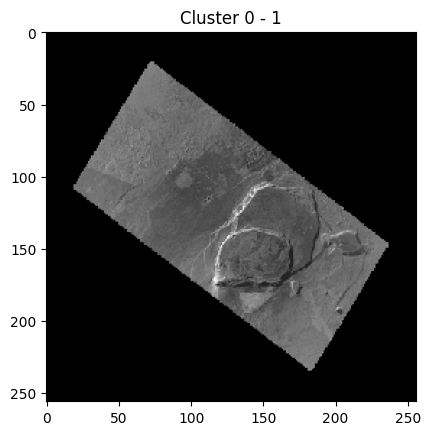

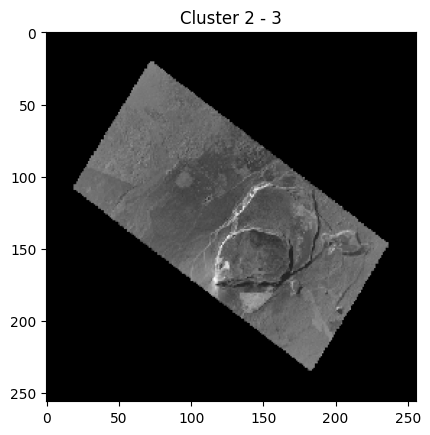

In [68]:
import matplotlib.pyplot as plt

for i in range(len(labels)):
    if labels[i] == 0:
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Cluster 0 - {i}")
        plt.show()
        break

for i in range(len(labels)):
    if labels[i] == 2:
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Cluster 2 - {i}")
        plt.show()
        break

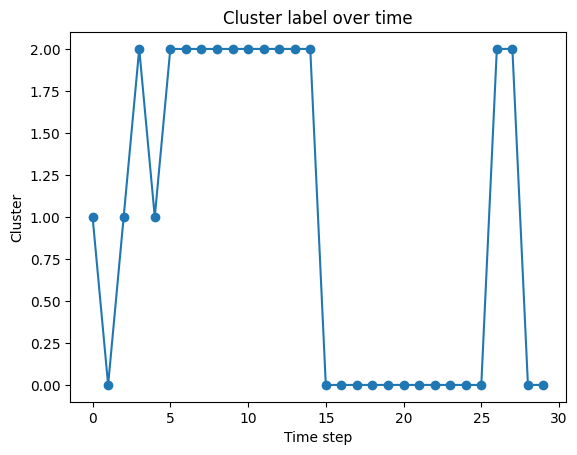

In [69]:
import matplotlib.pyplot as plt

plt.plot(labels, marker='o')
plt.title("Cluster label over time")
plt.xlabel("Time step")
plt.ylabel("Cluster")
plt.show()

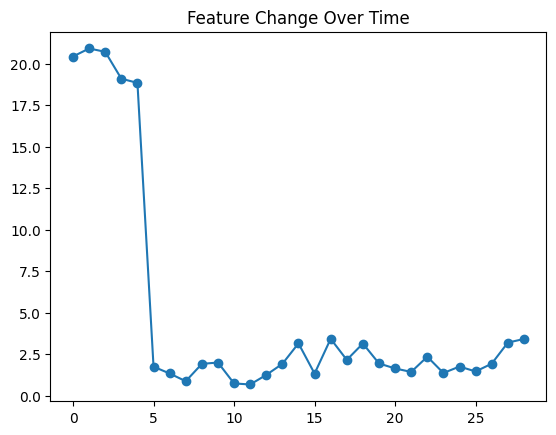

In [70]:
feature_changes = []

for i in range(len(features)-1):
    diff = np.linalg.norm(features[i] - features[i+1])
    feature_changes.append(diff)

plt.plot(feature_changes, marker='o')
plt.title("Feature Change Over Time")
plt.show()

In [73]:
#EXPERIMENT PIPELINE (PCA + GMM)
print("Feature shape:", features.shape)

Feature shape: (30, 65536)


In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Scaled shape:", features_scaled.shape)

Scaled shape: (30, 65536)


In [76]:
from sklearn.decomposition import PCA

pca_dims = [5, 10, 15, 20, 25]

pca_results = {}

for n in pca_dims:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(features_scaled)
    
    variance = sum(pca.explained_variance_ratio_)
    
    print(f"PCA={n}, Variance Retained={variance:.4f}")
    
    pca_results[n] = X_pca

PCA=5, Variance Retained=0.9493
PCA=10, Variance Retained=0.9774
PCA=15, Variance Retained=0.9891
PCA=20, Variance Retained=0.9948
PCA=25, Variance Retained=0.9982


In [81]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

results = {}

for n in pca_dims:
    X = pca_results[n]
    
    gmm = GaussianMixture(n_components=3, random_state=0)
    labels_gmm = gmm.fit_predict(X)
    
    score = silhouette_score(X, labels_gmm)
    
    print(f"PCA={n}, Silhouette Score={score:.4f}")
    
    results[n] = (labels_gmm, score)

PCA=5, Silhouette Score=0.7537
PCA=10, Silhouette Score=0.3377
PCA=15, Silhouette Score=0.3218
PCA=20, Silhouette Score=0.3137
PCA=25, Silhouette Score=0.3076


In [82]:
best_n = max(results, key=lambda x: results[x][1])

print("Best PCA:", best_n)
print("Best Score:", results[best_n][1])

labels_gmm = results[best_n][0]

Best PCA: 5
Best Score: 0.75370574


In [83]:
print("KMeans Labels:", labels)
print("GMM Labels:", labels_gmm)

KMeans Labels: [1 0 1 2 1 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0]
GMM Labels: [2 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [84]:
import numpy as np

print(dict(zip(*np.unique(labels_gmm, return_counts=True))))

{0: 27, 1: 1, 2: 2}


In [85]:
for i, lbl in enumerate(labels_gmm):
    item = temporal_stack[i]
    
    print(i,
          lbl,
          item.properties['sat:orbit_state'],
          item.properties['sar:observation_direction'],
          item.properties['view:incidence_angle'])

0 2 ascending right 54.1
1 0 ascending left 52.1
2 2 ascending right 54.1
3 0 ascending left 52.1
4 1 descending left 49.9
5 0 ascending left 52.1
6 0 ascending left 52.1
7 0 ascending left 52.1
8 0 ascending left 52.1
9 0 ascending left 52.1
10 0 ascending left 52.1
11 0 ascending left 52.1
12 0 ascending left 52.1
13 0 ascending left 52.1
14 0 ascending left 52.1
15 0 ascending left 52.1
16 0 ascending left 52.1
17 0 ascending left 52.1
18 0 ascending left 52.1
19 0 ascending left 52.1
20 0 ascending left 52.1
21 0 ascending left 52.1
22 0 ascending left 52.1
23 0 ascending left 52.1
24 0 ascending left 52.1
25 0 ascending left 52.1
26 0 ascending left 52.1
27 0 ascending left 52.1
28 0 ascending left 52.1
29 0 ascending left 52.1


In [86]:
#DBSCAN labels + score

In [88]:
X = pca_results[5]   # BEST PCA from your experiment

In [89]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=3)

labels_db = dbscan.fit_predict(X)

print("DBSCAN Labels:", labels_db)

DBSCAN Labels: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1]


In [91]:
import numpy as np

unique, counts = np.unique(labels_db, return_counts=True)

print("Cluster Distribution:")
print(dict(zip(unique, counts)))

Cluster Distribution:
{-1: 30}


In [92]:
import numpy as np
from sklearn.cluster import DBSCAN

X = pca_results[5]

for eps in [0.5, 1.0, 2.0, 3.0, 5.0]:
    db = DBSCAN(eps=eps, min_samples=3)
    labels_db = db.fit_predict(X)
    
    unique, counts = np.unique(labels_db, return_counts=True)
    
    print(f"\neps = {eps}")
    print(dict(zip(unique, counts)))


eps = 0.5
{-1: 30}

eps = 1.0
{-1: 30}

eps = 2.0
{-1: 30}

eps = 3.0
{-1: 30}

eps = 5.0
{-1: 30}
